In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("OK")

OK


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

cities = ["Casablanca", "Rabat", "Marrakech", "Tanger", "Fes", "Agadir"]

data = []

for i in range(100):
    city = np.random.choice(cities)
    surface = np.random.randint(60, 250)
    rooms = np.random.randint(2, 7)
    age = np.random.randint(0, 30)
    distance = np.random.randint(1, 20)

    base_price = {
        "Casablanca": 15000,
        "Rabat": 16000,
        "Marrakech": 12000,
        "Tanger": 11000,
        "Fes": 8000,
        "Agadir": 10000
    }

    price = (surface * base_price[city]) + (rooms * 50000) - (age * 10000) - (distance * 5000)

    data.append([city, surface, rooms, age, distance, int(price)])

df = pd.DataFrame(data, columns=[
    "City",
    "Surface_m2",
    "Rooms",
    "Age",
    "Distance_Center",
    "Price_MAD"
])

df.to_csv("morocco_real_estate_synthetic.csv", index=False)

print("Dataset created:", df.shape)

Dataset created: (100, 6)


In [ ]:
# ==============================================================================
# PROGETTO: Predizione dei Prezzi degli Immobili in Marocco
# STUDENTE: Asma Zaini
# MATRICOLA: 182161
# CORSO: Data Science e Laboratorio
# UNIVERSITÀ DEGLI STUDI DI UDINE
# ANNO ACCADEMICO: 2025/2026
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Impostazioni grafiche
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 120


# ==============================================================================
# 1. CARICAMENTO DATASET
# ==============================================================================

df = pd.read_csv("morocco_real_estate_synthetic.csv")

print("Dataset caricato correttamente")
print(df.head())


# ==============================================================================
# 2. ANALISI ESPLORATIVA DEI DATI (EDA)
# ==============================================================================

# Distribuzione prezzi

plt.figure(figsize=(8,5))
sns.histplot(df['Price_MAD']/1e6, kde=True, color='#d63384', bins=15)

plt.title("Distribuzione dei Prezzi degli Immobili", fontweight='bold')
plt.xlabel("Prezzo (Milioni MAD)")
plt.ylabel("Frequenza")

plt.savefig("grafico_1_distribuzione_prezzi.png")
plt.close()



# Prezzo medio per città

plt.figure(figsize=(8,5))

avg_price_city = df.groupby("City")["Price_MAD"].mean().sort_values()/1e6

sns.barplot(
    x=avg_price_city.values,
    y=avg_price_city.index,
    palette="magma"
)

plt.title("Prezzo Medio per Città", fontweight='bold')
plt.xlabel("Prezzo Medio (Milioni MAD)")
plt.ylabel("Città")

plt.savefig("grafico_2_prezzo_medio_citta.png")
plt.close()



# Relazione superficie-prezzo

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Surface_m2",
    y=df["Price_MAD"]/1e6,
    hue="City",
    s=100
)

plt.title("Relazione tra Superficie e Prezzo", fontweight='bold')
plt.xlabel("Superficie (m²)")
plt.ylabel("Prezzo (Milioni MAD)")

plt.savefig("grafico_3_superficie_vs_prezzo.png")
plt.close()



# Correlazione

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap="RdPu",
    fmt=".2f"
)

plt.title("Mappa di Correlazione", fontweight='bold')

plt.savefig("grafico_4_heatmap_correlazione.png")
plt.close()



# ==============================================================================
# 3. MACHINE LEARNING - LINEAR REGRESSION
# ==============================================================================

df_encoded = pd.get_dummies(
    df,
    columns=["City"],
    drop_first=True
)


X = df_encoded.drop("Price_MAD", axis=1)

y = df_encoded["Price_MAD"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)


y_pred = model.predict(X_test)



# ==============================================================================
# 4. RISULTATI DEL MODELLO
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test/1e6,
    y_pred/1e6,
    color="#9b59b6"
)

plt.plot(
    [y_test.min()/1e6, y_test.max()/1e6],
    [y_test.min()/1e6, y_test.max()/1e6],
    linestyle="--",
    color="#d63384"
)

plt.title("Valori Predetti vs Effettivi", fontweight='bold')
plt.xlabel("Prezzo Reale (Milioni MAD)")
plt.ylabel("Prezzo Predetto (Milioni MAD)")

plt.savefig("grafico_5_predicted_vs_actual.png")
plt.close()



# Importanza delle variabili

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})


coefficients["Absolute_Impact"] = coefficients["Coefficient"].abs()


importance = coefficients.sort_values(
    by="Absolute_Impact",
    ascending=False
)


plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Absolute_Impact",
    y="Feature",
    palette="magma"
)

plt.title("Importanza delle Feature", fontweight='bold')
plt.xlabel("Impatto sul Prezzo")
plt.ylabel("Feature")

plt.savefig("grafico_6_feature_importance.png")
plt.close()



print("Grafici generati con successo!")

Dataset caricato correttamente
        City  Surface_m2  Rooms  Age  Distance_Center  Price_MAD
0     Tanger         152      4    7                7    1767000
1      Rabat         134      4   23                4    2094000
2  Marrakech         209      6    1               12    2738000
3     Agadir          97      3   27                1     845000
4     Tanger         117      6   11               17    1392000


/tmp/ipykernel_3006/4033016074.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Grafici generati con successo!


/tmp/ipykernel_3006/4033016074.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


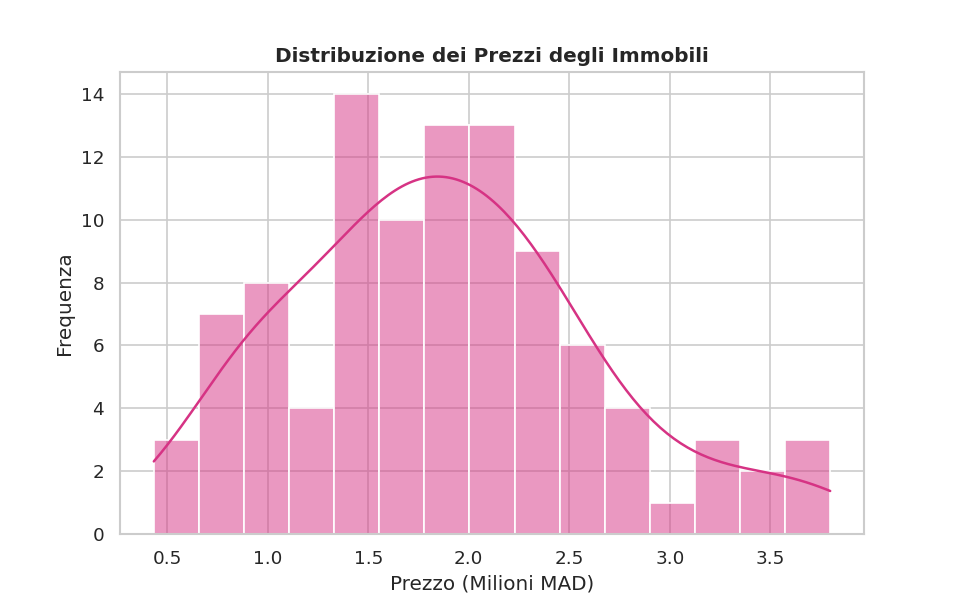

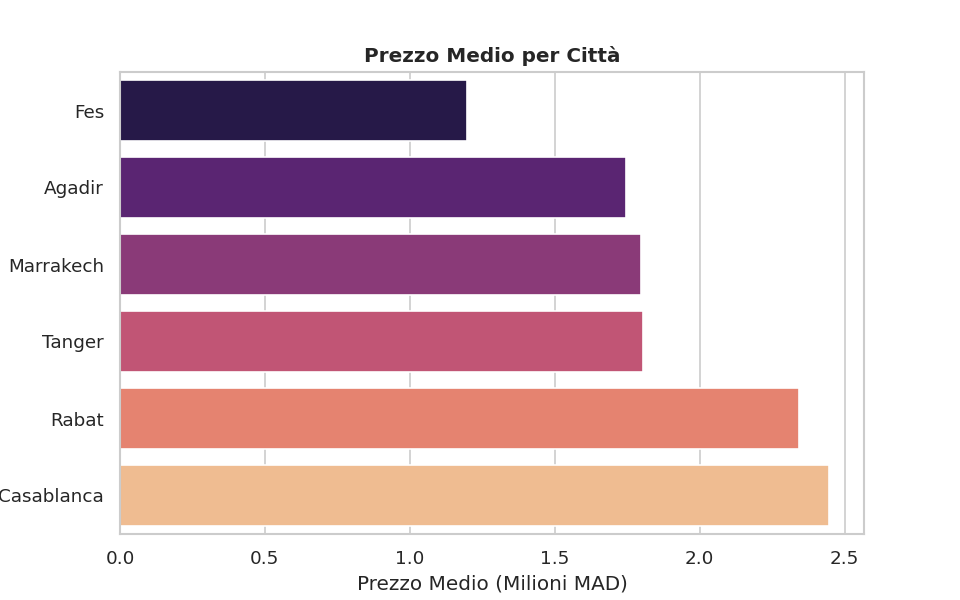

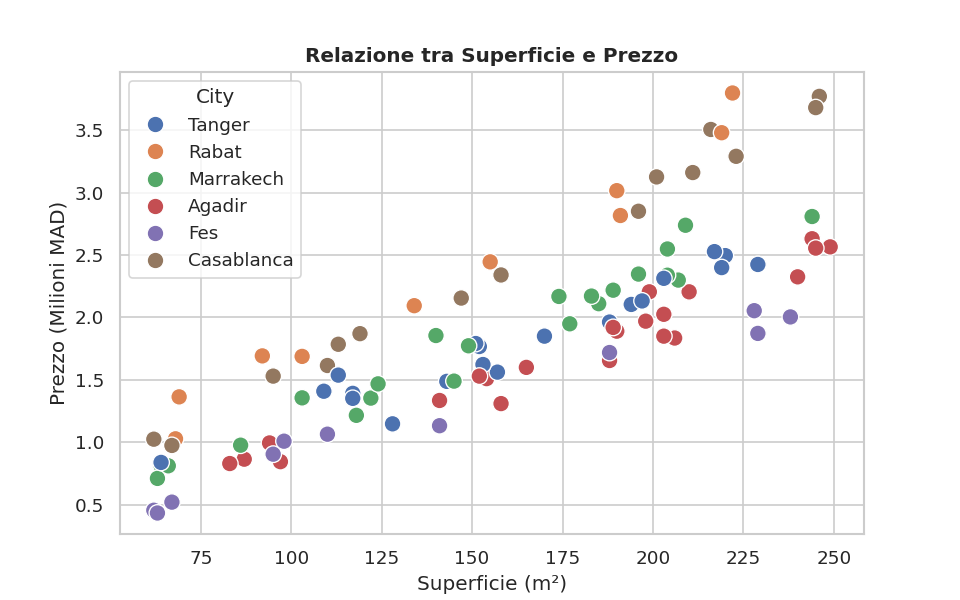

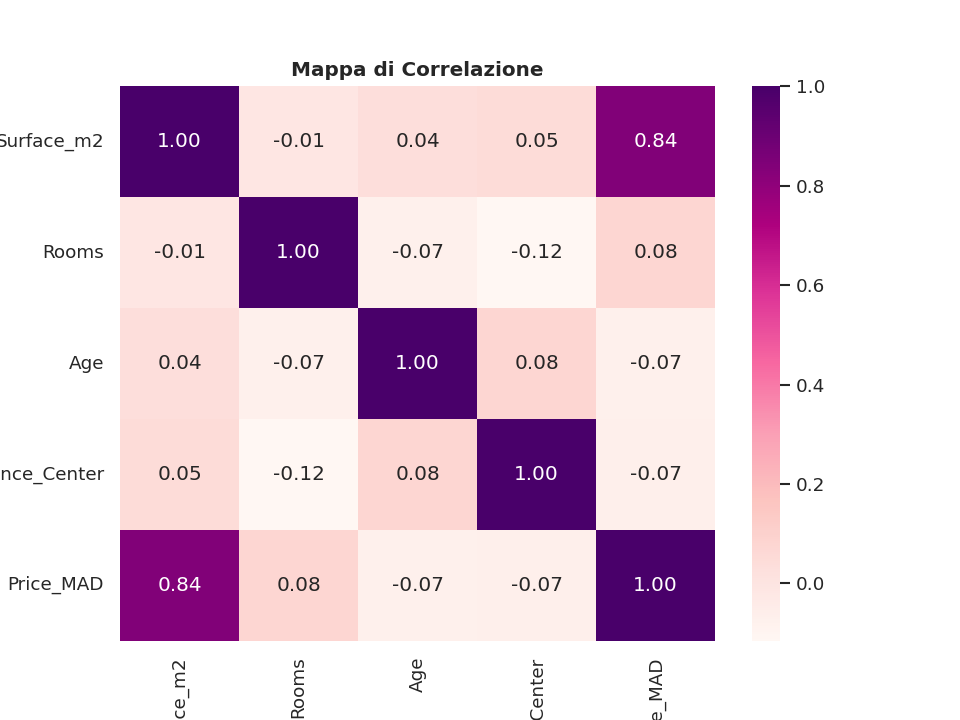

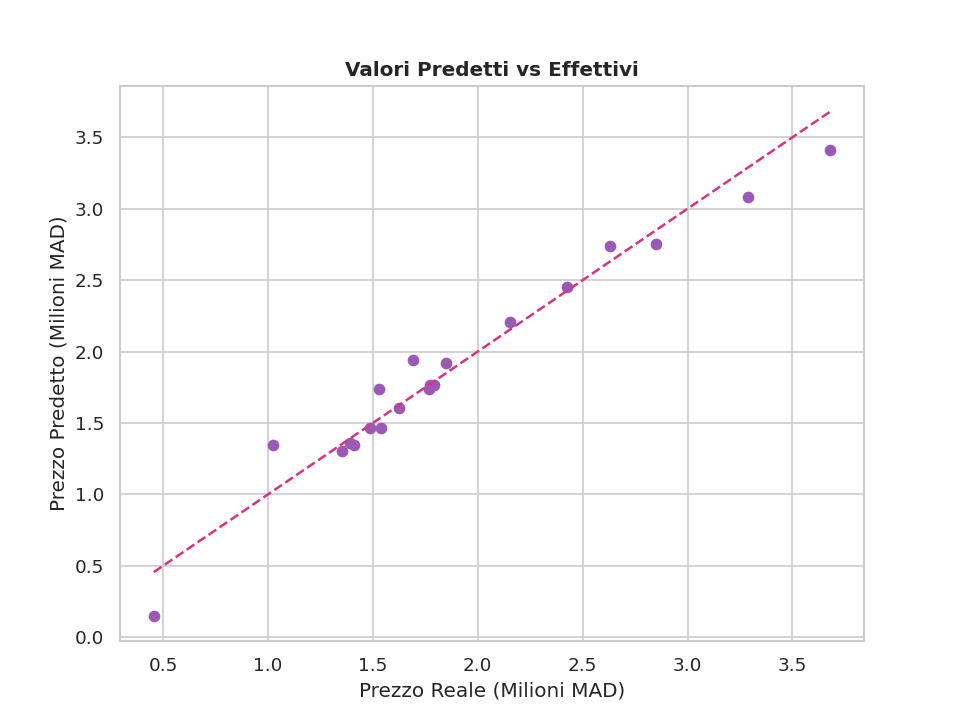

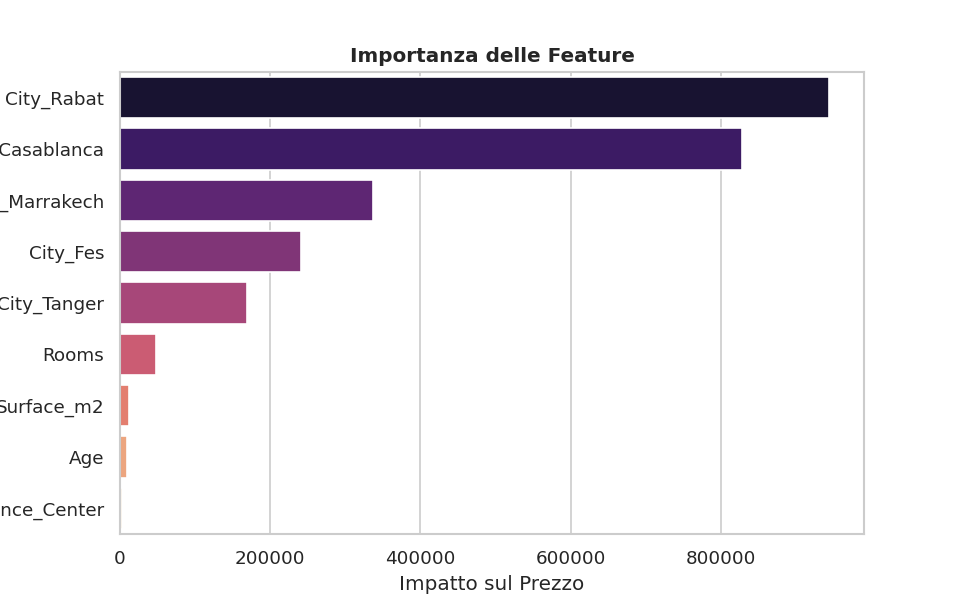

In [ ]:
from IPython.display import Image, display

display(Image("grafico_1_distribuzione_prezzi.png"))
display(Image("grafico_2_prezzo_medio_citta.png"))
display(Image("grafico_3_superficie_vs_prezzo.png"))
display(Image("grafico_4_heatmap_correlazione.png"))
display(Image("grafico_5_predicted_vs_actual.png"))
display(Image("grafico_6_feature_importance.png"))

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Valutazione del modello Linear Regression")
print("---------------------------------------")
print(f"MAE: {mae:.2f} MAD")
print(f"RMSE: {rmse:.2f} MAD")
print(f"R² Score: {r2:.2f}")

Valutazione del modello Linear Regression
---------------------------------------
MAE: 111305.16 MAD
RMSE: 151909.81 MAD
R² Score: 0.96


In [ ]:
from google.colab import drive
drive.mount('/content/drive')